In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw1-task2.ipynb")

# Homework 1 Task 2: Simple Linear Regression 
## Do eDNA and Traditional Sampling Detect the Same Number of Fish Species?


---

### Background

Environmental DNA (eDNA) sampling detects species by collecting and sequencing genetic material shed into the water — no nets or electrofishing required. Traditional methods require direct capture or observation. This dataset, the same as used in Task 1, compiles results from **68 freshwater lake surveys** across multiple published studies, comparing species detected by each method.

Your goal is to investigate whether **eDNA-based species richness** (`dna_richness`) can predict **traditional species richness** (`trad_richness`) — the number of species found by conventional gear. This is a question for conservation monitoring: if the two methods broadly agree, eDNA could replace expensive field surveys.

You will build and evaluate a simple linear regression model from scratch using NumPy, and then verify your results with `sklearn` and `statsmodels`.

---


The dataset has the following key columns:

| Column | Description |
|---|---|
| `author` | First author of the primary study |
| `area_ha` | Lake area (hectares) |
| `dna_richness` | Number of fish species detected by eDNA |
| `trad_richness` | Number of fish species detected by conventional surveys |
| `dna_only` | Number of species found **only** by eDNA |
| `trad_only` | Number of species found **only** by conventional surveys |
| `shared` | Number of species found by **both** methods |
| `union` | Total unique species (`dna_only + trad_only + shared`) |
| `marker_cat` | Whether single or multiple genetic markers were used (single vs. multiple eDNA markers) |
| `gear_cat` | Whether single or multiple conventional survey gear types were used (single vs. multiple) |
| `total_vol_liter` | Total volume of water sampled (litres) |

### Setup: Load libraries and read in data


In [2]:
# Load necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Read in data
df = pd.read_csv('lakes_data.csv') 

# View first 5 rows of the dataframe
df.head()

,author,year_pub,area_ha,dna_richness,trad_richness,dna_only,trad_only,shared,union,marker_count,locus,marker_cat,gear_cat,match_effort,field_reps,rep_vol_liter,total_vol_liter
0,Civade,2016,545.0,14,18,1,5,13,19,1,12s,single,single,yes,3,45.00,135.00
1,Doble,2020,3290000.0,92,62,41,11,51,103,4,12s_16s,multiple,single,yes,21,10.00,210.00
2,Evans,2017,2.0,15,10,5,0,10,15,3,12s_16s_cytb,multiple,multiple,yes,31,0.25,7.75
3,Fujii,2019,9.0,0,7,0,7,0,7,1,12s,single,multiple,no,1,1.00,1.00
4,Fujii,2019,5.0,2,8,0,6,2,8,1,12s,single,multiple,no,1,1.00,1.00


<!-- BEGIN QUESTION -->

---
## Step 1: Visualise the Relationship

Create an exploratory data visualization exploring the relationship between `dna_richness` and `trad_richness`. 

<Axes: title={'center': 'Fish Species Richness for DNA and Traditional Surveying'}, xlabel='DNA Richness (# of fish species detected)', ylabel='Traditional Richness (# of fish species detected)'>

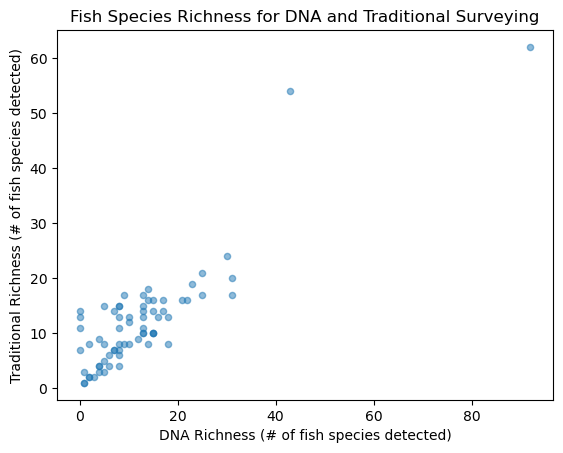

In [3]:
# Plot dna_richness versus traditional richness
df.plot(x = 'dna_richness',
        y = 'trad_richness',
        kind = 'scatter',
        alpha = 0.5,
        xlabel = 'DNA Richness (# of fish species detected)',
        ylabel = 'Traditional Richness (# of fish species detected)',
        title = 'Fish Species Richness for DNA and Traditional Surveying'
        )

> **Q1:** Does there appear to be a relationship between the two variables? Describe the direction, form, and approximate strength.

Yes, there seems to be a relationship between the number of fish when DNA and conventional surveys are used. As DNA richness increases, traditional richness increases. In other words as more fish are detected with DNA surveys more fish are detected with conventional surveys. The relationship appears to be linear. There is a positive correlation between DNA richness and traditional richness. The slope seems strong and positive but there are few data points upwards of approximately 35 fish detected with DNA surveys and approximately 25 fish detected with conventional surveys. The two data points above the clustered values could be distorting true trends. Further investigation is necessary to assess the true relationship between the two variables. 

<!-- END QUESTION -->

---
## Step 2: Fit the Regression 

Use `numpy` and the formula below to manually calculate β₁ and β₀. Store your coefficients in the `beta_1` and `beta_0` variables. Then, create a scatter plot of `trad_richness` and `dna_richness` (likely similar to the plot you created above!). Add the fitted line to the scatter plot, and the equation of the line as a legend item. 

$$\hat{\beta}_1 = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2} \qquad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1\bar{x}$$

In [4]:

# Calculate beta 1 manually
beta_1 = sum((df['dna_richness'] - df['dna_richness'].mean()) * (df['trad_richness'] - df['trad_richness'].mean()))/sum((df['dna_richness'] - df['dna_richness'].mean()) ** 2)

# Calculate beta 0 manually
beta_0 = df['trad_richness'].mean() - (beta_1 * df['dna_richness'].mean())

print(f"\u03b2\u2081     = {beta_1:.4f}")
print(f"\u03b2\u2080     = {beta_0:.4f}")

β₁     = 0.6519
β₀     = 4.0013


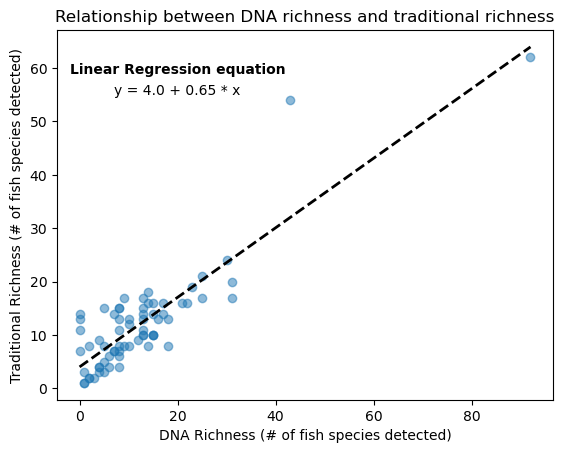

In [5]:
fig, ax = plt.subplots()

# Create a scatter plot from the df 
ax.scatter(x = df['dna_richness'],
           y = df['trad_richness'],
           alpha = 0.5)

# Define parameter of the regression
x_start = df['dna_richness'].min()
x_end = df['dna_richness'].max()

# Add the equation of the line 
reg_equation = 'y = '+ str(round(beta_0, 2)) + ' + ' + str(round(beta_1, 2)) + ' * x'
ax.text(20, 55, reg_equation, fontsize = 10, horizontalalignment = 'center')
ax.text(20, 59, 'Linear Regression equation', fontsize = 10, horizontalalignment = 'center', fontweight = 'bold')

# Add the linear regression line
ax.plot([x_start, x_end],
        [beta_1 * x_start + beta_0, beta_1 * x_end + beta_0],
        color = 'black',
        lw = 2,
        linestyle = "--")

# Add a table and axis labels
ax.set_title('Relationship between DNA richness and traditional richness')
ax.set_xlabel('DNA Richness (# of fish species detected)')
ax.set_ylabel('Traditional Richness (# of fish species detected)')

plt.show()


In [6]:
grader.check("q2")

q2 results: All test cases passed!

<!-- BEGIN QUESTION -->

---
## Step 3: Interpret the Coefficients



> **Q2:** Interpret the slope in plain language. Include units.





> **Q3:** Interpret the intercept. Is it ecologically meaningful?



**Q2**
For every fish detected by DNA survey methods there is on average a 0.6519 fish increase in the number of fish detected by conventional survey methods. The slope is positive. Though a fraction of a number of fish is not possible in the real world, the slope is an average meaning that the true slopes fall within a range surrounding the average value. The true value increases in the number of fish detected in conventional surveys for every increase in the number of fish detected in DNA surveys, would be whole number in real world scenarios. 

**Q3**
The x-intercept is approximately 4 meaning that when no fish are detected using the DNA survey method, on average 4 fish are detected using conventional methods. This is an ecologically meaningful value as conventional survey methods could be better at detecting fish when only a few species are present. This intercept emphasizes the importance of continuing to use conventional survey methods as overrelying on DNA survey methods could lead to believing no fish are present when few fish species exist in a body of water. 

<!-- END QUESTION -->

---
## Step 4: Compute Standard Errors

Use `numpy` and the formula below to manually calculate the standard errors. Store the RSE in a variable called `RSE`, the standard error of β₁ in a variable called `SE_beta_1`, and the standard error of β₀ in a variable called `SE_beta_0`. 

$$SS_{xx} = \sum(x_i - \bar{x})^2$$

$$RSE = \sqrt{\frac{RSS}{n-2}}$$

$$SE(\hat{\beta}_1) = \frac{RSE}{SS_{xx}}$$

$$SE(\hat{\beta}_0) = RSE \sqrt{\frac{1}{n} + \frac{\bar{x}^2}{SS_{xx}}}$$

In [7]:
# Calculate y hat and add it to the dataframe
df['y_hat'] = beta_0 + beta_1 * df['dna_richness']

# Calculate RSS
RSS = sum(((df['trad_richness'] - df['y_hat']) ** 2))
print(f"The RSS is {RSS:.4f}")


The RSS is 1485.4111


In [8]:
# Calculate the RSE
RSE       = np.sqrt(RSS/(len(df)-2))

# Calculate the standard errors of the betas
SE_beta_1 = RSE / np.sqrt(sum((df['dna_richness'] - df['dna_richness'].mean()) ** 2))
SE_beta_0 = RSE * np.sqrt((1/len(df)) + ((df['dna_richness'].mean() ** 2)/sum((df['dna_richness'] - df['dna_richness'].mean()) ** 2)))

print(f"RSE      = {RSE:.4f}  (species)")
print(f"SE(\u03b2\u2081)   = {SE_beta_1:.4f}")
print(f"SE(\u03b2\u2080)   = {SE_beta_0:.4f}")

RSE      = 4.7441  (species)
SE(β₁)   = 0.0446
SE(β₀)   = 0.7974


In [9]:
grader.check("q4")

q4 results: All test cases passed!

---
## Step 5: Manually Calculate 95% Confidence Intervals for $\beta_0$ and $\beta_1$

Using the formula below, manually calculate an approximate 95% confidence interval for β₀ and β₁. 

$$95\% \text{ CI} \simeq \hat{\beta}_i \pm 2 \times SE(\hat{\beta})$$

In [10]:
# Calculate the beta 1 confidence intervals
CI_beta_1_lower = beta_1 - (2 * SE_beta_1)
CI_beta_1_upper = beta_1 + (2 * SE_beta_1)

# Calculate the beta 0 confidence intervals
CI_beta_0_lower = beta_0 - (2 * SE_beta_0)
CI_beta_0_upper = beta_0 + (2 * SE_beta_0)

print(f"\n95% CI for \u03b2\u2081 (slope):  ({CI_beta_1_lower:.4f},  {CI_beta_1_upper:.4f})")
print(f"95% CI for \u03b2\u2080 (intercept): ({CI_beta_0_lower:.4f},  {CI_beta_0_upper:.4f})")


95% CI for β₁ (slope):  (0.5627,  0.7411)
95% CI for β₀ (intercept): (2.4064,  5.5962)


In [11]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q4:** Interpret the 95% CI for the slope in plain language.

There is a 95% chance that the true slope is beteen 0.5627 and 0.7411. This indicates that the slope is likely always positive. On average, for every one unit increase in `dna_richness`, the species detected through DNA surveys, there is a between 0.5627 and 0.7411 unit increase in `trad_richness`, the species detected with conventional survey methods. In other words, on average, for every one species increase in the number of species detected through DNA surveys there is between a 0.5627 and 0.7411 increase in the number of species detected when conventional survey methods are used. 

<!-- END QUESTION -->

---
## Step 6: Assess Model Accuracy — R²

Manually calculate the R² using the formula below. Store your answer in the `R2` variable. 

$$R^2 = 1 - \frac{RSS}{TSS} \qquad TSS = \sum_{i=1}^{n}(y_i - \bar{y})^2$$

In [12]:
# Manually calculate the R2
R2     = 1 - (RSS / sum((df['trad_richness'] - df['trad_richness'].mean()) ** 2))

print(f"R\u00b2     = {R2:.4f}")

R²     = 0.7640


In [13]:
grader.check("q7")

q7 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q5:** Interpret the R² in the context of this problem.

The calculated R² value is 0.7640 meaning that our linear regression model accounts for 76.4 % of the variance. This shows that the model is relatively good at explaining the variability of our data. The model is a good fit for our data. In the context of our data, the R² indicates that positive correlation as determined in the linear regression equation describes the relationship between `dna_richness` and `trad_richness` well. 

<!-- END QUESTION -->

---
## Step 7: Verify with `sklearn`

Let's confirm our manual OLS results using `sklearn`'s `LinearRegression`.

> **Note:** `sklearn` expects a 2D feature matrix, so we need to reshape `X` from
> shape `(n,)` to `(n, 1)` using `.reshape(-1, 1)` before fitting.

1. **Fit the model** — `LinearRegression().fit(X_2d, Y)` finds the same OLS solution as
   our manual β₁ and β₀ formulas.
2. **Extract coefficients** — `.coef_[0]` is the slope, `.intercept_` is the intercept.
3. **Compute R²** — `r2_score(Y, y_pred)` uses the $R^2 = 1 - RSS/TSS$. formula, where `y_pred = your_fitted_model.predict(X_2d)`
   
4. Create a table that compares the manually calculated and `LinearRegression()` generated slope, intercept, and R². 

If your manual calculations are correct, all three values should match `sklearn`'s output
to at least four decimal places. Any discrepancy beyond floating-point rounding
indicates a bug in your manual formulas.

In [14]:
# Save x and y to variables
x = df['dna_richness']
y = df['trad_richness']

# Reshape x to a 2d feature matrix
x_matrix = np.array(x).reshape(-1, 1)

# Fit the linear regression model with sklearn
reg = LinearRegression().fit(x_matrix, y)

# Save the predicted y hat values
y_pred = reg.predict(x_matrix)

# Extract the coefficients
sk_slope     = reg.coef_[0]
sk_intercept = reg.intercept_

# Calculate R2
sk_r2        = r2_score(y, y_pred)

print(f"sklearn  slope     = {sk_slope:.4f},  manual slope     = {beta_1:.4f}")
print(f"sklearn  intercept = {sk_intercept:.4f},  manual intercept = {beta_0:.4f}")
print(f"sklearn  R\u00b2        = {sk_r2:.4f},  manual R\u00b2        = {R2:.4f}")

sklearn  slope     = 0.6519,  manual slope     = 0.6519
sklearn  intercept = 4.0013,  manual intercept = 4.0013
sklearn  R²        = 0.7640,  manual R²        = 0.7640


In [15]:
grader.check("q9")

q9 results: All test cases passed!

---
## Step 8: Verify with `statsmodels` 

`sklearn` is optimized for **prediction**: it fits models efficiently and scores them, but it deliberately leaves out statistical inference (standard errors, p-values, confidence intervals).

`statsmodels` is designed for **inference**: it fits the same OLS model but reports the full regression table — coefficients, standard errors, t-statistics, p-values, and confidence intervals — matching what you'd see in a statistics textbook.


1. Import `statsmodels.api as sm`.
2. Add a constant (intercept) column to `X` using `sm.add_constant()`.
3. Fit the model with `sm.OLS(Y, X_sm).fit()` and call `.summary()` to display the full regression table.
4. Extract the slope, intercept, and R² from the fitted model and compare them to your numpy and sklearn results. Store the statsmodels slope in `sm_slope`, the intercept in `sm_intercept`, and R² in `sm_r2`.

If all three methods are correct, the coefficients and R² should match to at least four decimal places.

In [16]:
# Import the statsmodels library
import statsmodels.api as sm

# Add a constant intercept 
x_sm = sm.add_constant(x)

# Fit the linear regression model with statsmodels function
statsmodel = sm.OLS(y, x_sm).fit()

# Print out the summary table
print(statsmodel.summary())

# Save the coefficients' values and R2 value 
sm_intercept = statsmodel.params['const']
sm_slope     = statsmodel.params['dna_richness']
sm_r2        = statsmodel.rsquared


                            OLS Regression Results                            
Dep. Variable:          trad_richness   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.760
Method:                 Least Squares   F-statistic:                     213.7
Date:                Sat, 11 Apr 2026   Prob (F-statistic):           2.25e-22
Time:                        17:30:16   Log-Likelihood:                -201.34
No. Observations:                  68   AIC:                             406.7
Df Residuals:                      66   BIC:                             411.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            4.0013      0.797      5.018   

In [17]:
grader.check("q10")

q10 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q6:** Look at the **p-values** for the slope (`dna_richness`) and intercept (`const`) in the statsmodels summary.
>
> - What does the p-value for the **slope** tell you? Is the relationship between eDNA richness and traditional richness statistically significant? How do you know?


The p-value is less than the typically used threshold of 0.05. The slope determined by this linear regression model is statistically significant. The relationship between `dna_richness` and `trad_richness` are statistically significant. There is less than a 5% chance that the finding that the slope is approximately 0.65 on average is based on chance alone. There is strong evidence that the correlation between `dna_richness` and `trad_richness` is positive.

The p-value for the intercept is also less than 0.05 meaning that it is a statistically significant finding. There is strong evidence that when no species are detected by the DNA survey method approximately 4 species are detected on average by the conventional survey methods. 

<!-- END QUESTION -->



---

**Run the cell below to receive credit for all auto graded questions.**

In [18]:
grader.check_all()

q10 results: All test cases passed!

q2 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!

q7 results: All test cases passed!

q9 results: All test cases passed!